# Assignment: Linear Models


**Q1.** Please answer the following questions in your own words.

1. What makes a model "linear"? "Linear" in what?

A linear model is linear in its parameters even if the variables are x^2 or x^3 or whatever, which means that each variable"s value is multiplied by a single constant coefficient to predict the y.

2. How do you interpret the coefficient for a dummy/one-hot-encoded variable? (This is a trick question, and the trick involves how you handle the intercept of the model.)

It depends what you've decided your baseline to be, because one of your dummies turns into your intercept (or drop the intercept). The coefficient represents the effect on the predicted output that a true value for that dummy has.

3. Can linear regression be used for classification? Explain why, or why not.

No, because you must use logitic regression in order to classify outcomes into true or false (1,0)

4. What are signs that your linear model is over-fitting?

too many variables (unexplainiable feature space, many interaction terms). Also if you test very poorly on your test split.

5. Clearly explain multi-colinearity using the two-stage least squares technique.

It's when two variables are very similar and thus affect the y very similarly, making it difficult to extract their particular predictive contributions. You need an instrumental variable to do this.

6. How can you incorporate nonlinear relationships between your target/response/dependent/outcome variable $y$ and your features/control/response/independent variables $x$ into your analysis?

By trying out a larger feature space with different exponentials, logs, etc, as well as interaction terms

7. What is the interpretation of the intercept? A slope coefficient for a variable? The coefficient for a dummy/one-hot-encoded variable?

Intercept is the model's guess in the event all independent variables are zero. A slope coefficient is the particular marginal effect of a variable's value on the prediction. The dummy coefficient is the marginal effect on prediction should a condition be true.

**Q2.** Load `./data/Q1_clean.csv`. The data include

- `Price` per night
- `Review Scores Rating`: The average rating for the property
- `Neighbourhood `: The bourough of NYC. Note the space, or rename the variable.
- `Property Type`: The kind of dwelling
- `Room Type`: The kind of space being rented

1. Compute the average prices and scores by `Neighbourhood `; which bourough is the most expensive on average? Create a kernel density plot of price and log price, grouping by `Neighbourhood `.
2. Regress price on `Neighbourhood ` by creating the appropriate dummy/one-hot-encoded variables, without an intercept in the linear model and using all the data. Compare the coefficients in the regression to the table from part 1. What pattern do you see? What are the coefficients in a regression of a continuous variable on one categorical variable?
3. Repeat part 2, but leave an intercept in the linear model. How do you have to handle the creation of the dummies differently? What is the intercept? Interpret the coefficients. How can I get the coefficients in part 2 from these new coefficients?
4. Split the sample 80/20 into a training and a test set. Run a regression of `Price` on `Review Scores Rating` and `Neighbourhood `. What is the $R^2$ and RMSE on the test set? What is the coefficient on `Review Scores Rating`? What is the most expensive kind of property you can rent?
5. Split the sample 80/20 into a training and a test set. Run a regression of `Price` on `Review Scores Rating` and `Neighbourhood ` and `Property Type`. What is the $R^2$ and RMSE on the test set? What is the coefficient on `Review Scores Rating`? What is the most expensive kind of property you can rent?
6. What does the coefficient on `Review Scores Rating` mean if it changes from part 4 to 5? Hint: Think about how multilple linear regression works.
7. (Optional) We've included `Neighborhood ` and `Property Type` separately in the model. How do you interact them, so you can have "A bedroom in Queens" or "A townhouse in Manhattan". Split the sample 80/20 into a training and a test set and run a regression including that kind of "property type X neighborhood" dummy, plus `Review Scores Rating`. How does the slope coefficient for `Review Scores Rating`, the $R^2$, and the RMSE change? Do they increase significantly compares to part 5? Are the coefficients in this regression just the sum of the coefficients for `Neighbourhood ` and `Property Type` from 5? What is the most expensive kind of property you can rent?

In [32]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm

df = pd.read_csv('/Q1_clean.csv')
df.rename(columns={'Neighbourhood ': 'Neighbourhood'}, inplace=True)
print(df.columns)
df.head()

Index(['Price', 'Review Scores Rating', 'Neighbourhood', 'Property Type',
       'Room Type'],
      dtype='object')


,Price,Review Scores Rating,Neighbourhood,Property Type,Room Type
0,549,96.0,Manhattan,Apartment,Private room
1,149,100.0,Brooklyn,Apartment,Entire home/apt
2,250,100.0,Manhattan,Apartment,Entire home/apt
3,90,94.0,Brooklyn,Apartment,Private room
4,270,90.0,Manhattan,Apartment,Entire home/apt


                    Price  Review Scores Rating
Neighbourhood                                  
Bronx           75.276498             91.654378
Brooklyn       127.747378             92.363497
Manhattan      183.664286             91.801496
Queens          96.857233             91.549057
Staten Island  146.166667             90.843750


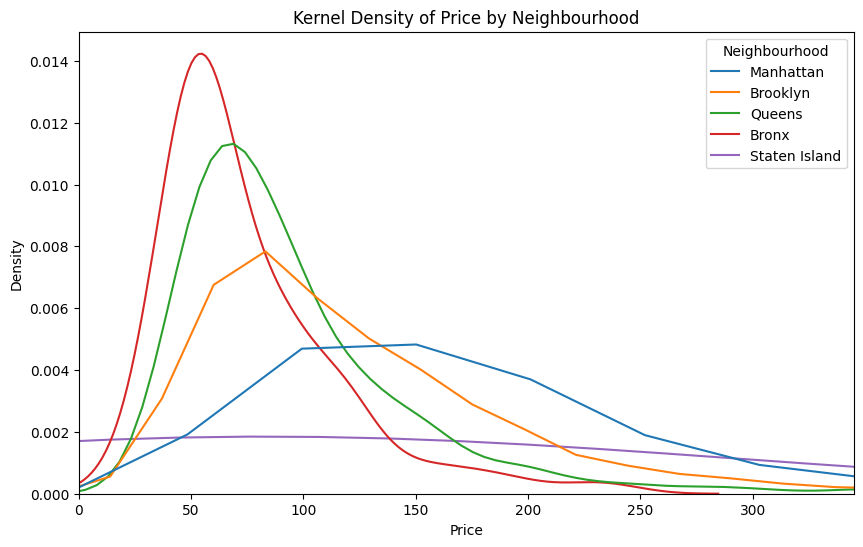

In [33]:
# Q1: Manhattan is the most expensive neighbourhood on average
neigh_summary = df.groupby('Neighbourhood').agg({
    'Price': 'mean',
    'Review Scores Rating': 'mean'
})
print(neigh_summary)

plt.figure(figsize=(10,6))
sns.kdeplot(data=df, x='Price', hue='Neighbourhood', common_norm=False)
plt.title('Kernel Density of Price by Neighbourhood')
plt.xlim(0, df['Price'].quantile(0.95))
plt.show()

In [35]:
# Q2: The coefficients from regression are the average price values of each neighborhood. That means the coefficients are group means.
dummies = pd.get_dummies(df['Neighbourhood'])
model = sm.OLS(df['Price'], dummies).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.046
Model:                            OLS   Adj. R-squared:                  0.046
Method:                 Least Squares   F-statistic:                     268.9
Date:                Mon, 23 Mar 2026   Prob (F-statistic):          4.43e-226
Time:                        17:03:19   Log-Likelihood:            -1.4174e+05
No. Observations:               22153   AIC:                         2.835e+05
Df Residuals:                   22148   BIC:                         2.835e+05
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Bronx            75.2765      9.868      7.628

In [45]:
# Q3: Now I have to drop a dummy, so Bronx becomes the intercept. If you add the coefficient to the intercept, you get the coefficient from part 2.
# These coefficients are how much more/less average price is compared to Bronx average
df['Price'] = df['Price'].astype(str) \
                       .str.replace(r'[\$,]', '', regex=True) \
                       .str.strip()
df['Price'] = pd.to_numeric(df['Price'], errors='coerce')
df = df.dropna(subset=['Price', 'Neighbourhood'])
df['Price'] = df['Price'].astype(float)
dummies = pd.get_dummies(df['Neighbourhood'], drop_first=True, dtype=float)
X = sm.add_constant(dummies)
y = df['Price']
model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.046
Model:                            OLS   Adj. R-squared:                  0.046
Method:                 Least Squares   F-statistic:                     268.9
Date:                Mon, 23 Mar 2026   Prob (F-statistic):          4.43e-226
Time:                        17:11:04   Log-Likelihood:            -1.4174e+05
No. Observations:               22153   AIC:                         2.835e+05
Df Residuals:                   22148   BIC:                         2.835e+05
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const            75.2765      9.868      7.628

In [53]:
# Q4: R^2 is .051 and RMSE is 140.9, coefficient on RSR is 1.21, and most expensive property type is a condo
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

train, test = train_test_split(df, test_size=0.2, random_state=42)
neigh_dummies_train = pd.get_dummies(train['Neighbourhood'], drop_first=True, dtype=float)
X_train = pd.concat([train[['Review Scores Rating']], neigh_dummies_train], axis=1)
X_train = sm.add_constant(X_train)
y_train = train['Price']
model = sm.OLS(y_train, X_train).fit()
print(model.summary())

neigh_dummies_test = pd.get_dummies(test['Neighbourhood'], drop_first=True, dtype=float)
for col in X_train.columns:
    if col not in neigh_dummies_test.columns and col not in ['const', 'Review Scores Rating']:
        neigh_dummies_test[col] = 0
X_test = pd.concat([test[['Review Scores Rating']], neigh_dummies_test[X_train.columns[2:]]], axis=1)
X_test = sm.add_constant(X_test)
y_test = test['Price']
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
print("Test set RMSE:", rmse)
avg_price_property = df.groupby('Property Type')['Price'].mean().sort_values(ascending=False)
most_expensive_type = avg_price_property.index[0]
most_expensive_price = avg_price_property.iloc[0]
print("Most expensive property type:", most_expensive_type)
print("Average price:", most_expensive_price)

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.051
Model:                            OLS   Adj. R-squared:                  0.051
Method:                 Least Squares   F-statistic:                     189.8
Date:                Mon, 23 Mar 2026   Prob (F-statistic):          1.33e-197
Time:                        17:18:01   Log-Likelihood:            -1.1348e+05
No. Observations:               17722   AIC:                         2.270e+05
Df Residuals:                   17716   BIC:                         2.270e+05
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                  -35.1573 

In [57]:
# Q5: R^2 is .06, RMSE is 140.3, RSR coefficient is 1.20, and condo remains most expensive.
train, test = train_test_split(df, test_size=0.2, random_state=42)
neigh_dummies_train = pd.get_dummies(train['Neighbourhood'], drop_first=True, dtype=float)
type_dummies_train = pd.get_dummies(train['Property Type'], drop_first=True, dtype=float)
X_train = pd.concat([train[['Review Scores Rating']], neigh_dummies_train, type_dummies_train], axis=1)
X_train = sm.add_constant(X_train)
y_train = train['Price']
model = sm.OLS(y_train, X_train).fit()
print(model.summary())
print("Coefficient on Review Scores Rating:", model.params['Review Scores Rating'])
neigh_dummies_test = pd.get_dummies(test['Neighbourhood'], drop_first=True, dtype=float)
type_dummies_test = pd.get_dummies(test['Property Type'], drop_first=True, dtype=float)
for col in X_train.columns[1:]:
    if col not in neigh_dummies_test.columns and col not in type_dummies_test.columns and col != 'Review Scores Rating':
                if col in neigh_dummies_train.columns:
                  neigh_dummies_test[col] = 0
                else:
                  type_dummies_test[col] = 0
X_test = pd.concat([test[['Review Scores Rating']], neigh_dummies_test[X_train.columns[2:len(neigh_dummies_train.columns)+2]],
                    type_dummies_test[X_train.columns[len(neigh_dummies_train.columns)+2:]]], axis=1)
X_test = sm.add_constant(X_test)
y_test = test['Price']
y_pred = model.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("Test set RMSE:", rmse)
avg_price_property = df.groupby('Property Type')['Price'].mean().sort_values(ascending=False)
most_expensive_type = avg_price_property.index[0]
most_expensive_price = avg_price_property.iloc[0]
print("Most expensive property type:", most_expensive_type)
print("Average price:", most_expensive_price)

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.060
Model:                            OLS   Adj. R-squared:                  0.059
Method:                 Least Squares   F-statistic:                     51.46
Date:                Mon, 23 Mar 2026   Prob (F-statistic):          2.52e-218
Time:                        17:19:59   Log-Likelihood:            -1.1339e+05
No. Observations:               17722   AIC:                         2.268e+05
Df Residuals:                   17699   BIC:                         2.270e+05
Df Model:                          22                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                  -49.2960 

In [ ]:
# Q6: Because the RSR coefficient decreases from Q4 to Q5, we can attribute some of the variation that
# used to be attributable to RSR to property type instead, because we are giving the MLR more data points to work with

**Q3.** This question is a case study for linear models. The data are about car prices. In particular, they include:

  - `Price`, `Color`, `Seating_Capacity`
  - `Body_Type`: crossover, hatchback, muv, sedan, suv
  - `Make`, `Make_Year`: The brand of car and year produced
  - `Mileage_Run`: The number of miles on the odometer
  - `Fuel_Type`: Diesel or gasoline/petrol
  - `Transmission`, `Transmission_Type`:  speeds and automatic/manual

  1. Load `cars_hw.csv`. These data were really dirty, and I've already cleaned them a significant amount in terms of missing values and other issues, but some issues remain (e.g. outliers, badly scaled variables that require a log or arcsinh transformation). Clean the data however you think is most appropriate.
  2. Summarize the `Price` variable and create a kernel density plot. Use `.groupby()` and `.describe()` to summarize prices by brand (`Make`). Make a grouped kernel density plot by `Make`. Which car brands are the most expensive? What do prices look like in general?
  3. Split the data into an 80% training set and a 20% testing set.
  4. Make a model where you regress price on the numeric variables alone; what is the $R^2$ and `RMSE` on the training set and test set? Make a second model where, for the categorical variables, you regress price on a model comprised of one-hot encoded regressors/features alone (you can use `pd.get_dummies()`; be careful of the dummy variable trap); what is the $R^2$ and `RMSE` on the test set? Which model performs better on the test set? Make a third model that combines all the regressors from the previous two; what is the $R^2$ and `RMSE` on the test set? Does the joint model perform better or worse, and by home much?
  5. Use the `PolynomialFeatures` function from `sklearn` to expand the set of numerical variables you're using in the regression. As you increase the degree of the expansion, how do the $R^2$ and `RMSE` change? At what point does $R^2$ go negative on the test set? For your best model with expanded features, what is the $R^2$ and `RMSE`? How does it compare to your best model from part 4?
  6. For your best model so far, determine the predicted values for the test data and plot them against the true values. Do the predicted values and true values roughly line up along the diagonal, or not? Compute the residuals/errors for the test data and create a kernel density plot. Do the residuals look roughly bell-shaped around zero? Evaluate the strengths and weaknesses of your model.

In [59]:
# Q1
df = pd.read_csv('/cars_hw.csv')
print(df.columns)
df.head()

Index(['Unnamed: 0', 'Make', 'Make_Year', 'Color', 'Body_Type', 'Mileage_Run',
       'No_of_Owners', 'Seating_Capacity', 'Fuel_Type', 'Transmission',
       'Transmission_Type', 'Price'],
      dtype='object')


,Unnamed: 0,Make,Make_Year,Color,Body_Type,Mileage_Run,No_of_Owners,Seating_Capacity,Fuel_Type,Transmission,Transmission_Type,Price
0,1,Volkswagen,2017,silver,sedan,44611,1st,5,diesel,7-Speed,Automatic,657000
1,2,Hyundai,2016,red,crossover,20305,1st,5,petrol,5-Speed,Manual,682000
2,3,Honda,2019,white,suv,29540,2nd,5,petrol,5-Speed,Manual,793000
3,4,Renault,2017,bronze,hatchback,35680,1st,5,petrol,5-Speed,Manual,414000
4,5,Hyundai,2017,orange,hatchback,25126,1st,5,petrol,5-Speed,Manual,515000


count    9.760000e+02
mean     7.410195e+05
std      3.673234e+05
min      1.880000e+05
25%      4.757500e+05
50%      6.665000e+05
75%      8.830000e+05
max      2.941000e+06
Name: Price, dtype: float64


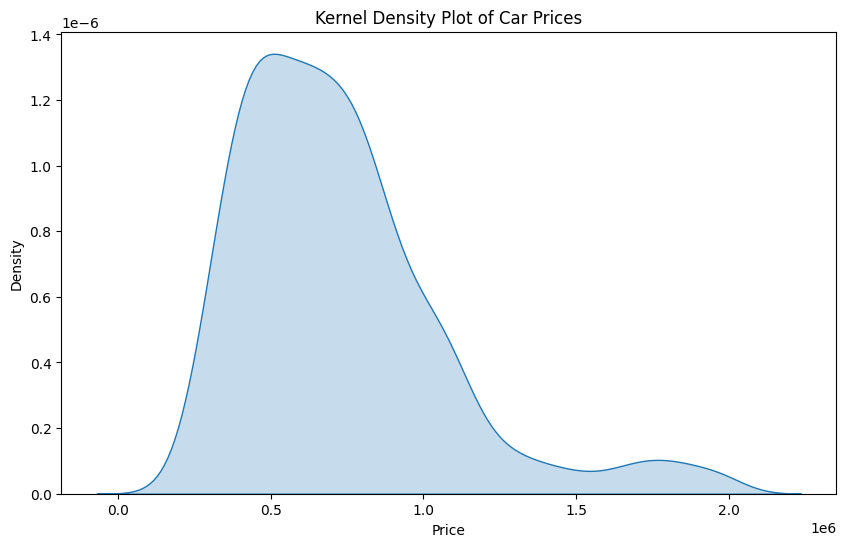

               count          mean           std        min        25%  \
Make                                                                     
Chevrolet        6.0  4.535000e+05  2.466064e+05   267000.0   288500.0   
Datsun           3.0  2.896667e+05  1.050397e+04   279000.0   284500.0   
Ford            52.0  7.211731e+05  1.409277e+05   290000.0   635000.0   
Honda           73.0  7.989726e+05  2.665091e+05   316000.0   581000.0   
Hyundai        305.0  6.918918e+05  2.791597e+05   248000.0   485000.0   
Jeep             4.0  1.499500e+06  1.525134e+05  1290000.0  1447500.0   
Kia              8.0  1.614750e+06  1.190567e+05  1369000.0  1579000.0   
MG Motors       35.0  1.869457e+06  1.216611e+05  1589000.0  1786500.0   
Mahindra        18.0  1.100167e+06  1.755493e+05   796000.0  1037000.0   
Maruti Suzuki  293.0  5.887850e+05  2.160199e+05   237000.0   411000.0   
Nissan           4.0  8.842500e+05  2.895599e+05   475000.0   782500.0   
Renault         68.0  6.625735e+05  2.

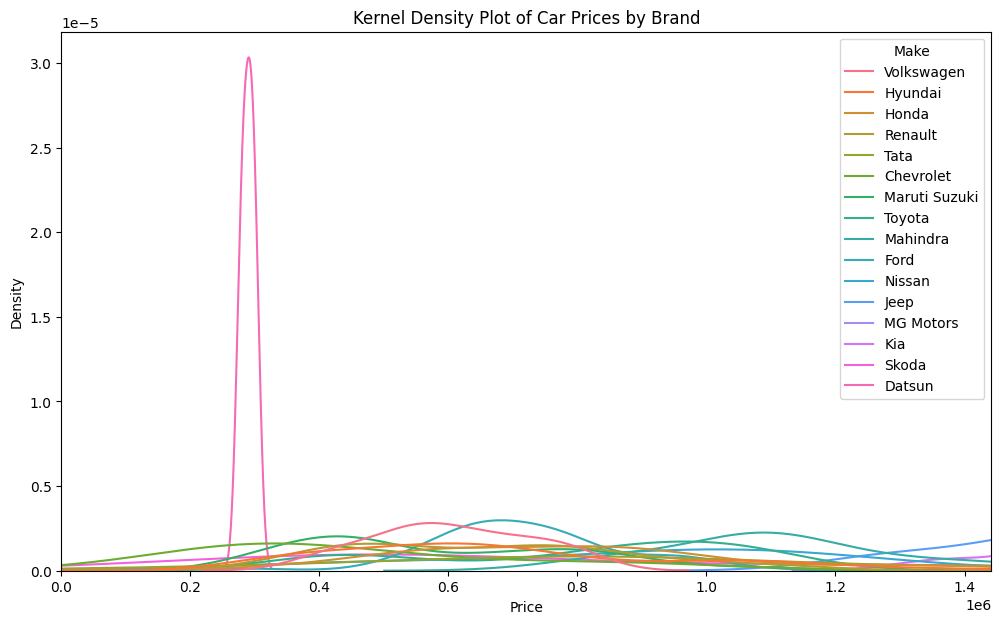

In [63]:
# Q2: It looks like MG motors has the most expensive cars on average. Prices generally seem to be concentrated on the lower end of prices,
# but a larg portionof that appears to be due to Skoda's spike at one price level
print(df['Price'].describe())
df_clean = df[df['Price'] < df['Price'].quantile(0.99)]
plt.figure(figsize=(10,6))
sns.kdeplot(df_clean['Price'], fill=True)
plt.title('Kernel Density Plot of Car Prices')
plt.xlabel('Price')
plt.ylabel('Density')
plt.show()
brand_summary = df.groupby('Make')['Price'].describe()
print(brand_summary)
plt.figure(figsize=(12,7))
sns.kdeplot(data=df_clean, x='Price', hue='Make', common_norm=False)
plt.title('Kernel Density Plot of Car Prices by Brand')
plt.xlabel('Price')
plt.ylabel('Density')
plt.xlim(0, df_clean['Price'].quantile(0.95))  # limit x-axis for readability
plt.show()

In [64]:
# Q3
train, test = train_test_split(df, test_size=0.2, random_state=42)

In [73]:
# Q4: Check output for R^2 and RMSE. The joint model performs much better than only numeric, and moderately better than only categorical.
numeric_cols = train.select_dtypes(include=np.number).columns.tolist()
numeric_cols.remove('Price')
X_train_num = train[numeric_cols]
X_train_num = sm.add_constant(X_train_num)
y_train = train['Price']
X_test_num = test[numeric_cols]
X_test_num = sm.add_constant(X_test_num)
y_test = test['Price']
model_num = sm.OLS(y_train, X_train_num).fit()
y_train_pred = model_num.predict(X_train_num)
rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
print("Model 1 (Numeric only) - Training R²:", model_num.rsquared)
print("Model 1 - Training RMSE:", rmse_train)
y_test_pred = model_num.predict(X_test_num)
rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))
print("Model 1 - Test R²:", model_num.rsquared)
print("Model 1 - Test RMSE:", rmse_test)

cat_cols = [c for c in train.select_dtypes(include='object').columns if c != 'Price']
X_train_cat = pd.get_dummies(train[cat_cols], drop_first=True, dtype=float)
y_train = train['Price']
X_test_cat = pd.get_dummies(test[cat_cols], drop_first=True, dtype=float)
X_test_cat = X_test_cat.reindex(columns=X_train_cat.columns, fill_value=0)
X_train_cat = sm.add_constant(X_train_cat)
X_test_cat = sm.add_constant(X_test_cat)
y_test = test['Price']
model_cat = sm.OLS(y_train, X_train_cat).fit()
y_train_pred = model_cat.predict(X_train_cat)
rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
print("Model 2 (Categorical only) - Training R²:", model_cat.rsquared)
print("Model 2 - Training RMSE:", rmse_train)
y_test_pred = model_cat.predict(X_test_cat)
rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))
print("Model 2 - Test RMSE:", rmse_test)

numeric_cols = train.select_dtypes(include=np.number).columns.tolist()
numeric_cols.remove('Price')
cat_cols = [c for c in train.select_dtypes(include='object').columns if c != 'Price']
X_train_cat = pd.get_dummies(train[cat_cols], drop_first=True, dtype=float)
X_test_cat = pd.get_dummies(test[cat_cols], drop_first=True, dtype=float)
X_test_cat = X_test_cat.reindex(columns=X_train_cat.columns, fill_value=0)
X_train_all = pd.concat([train[numeric_cols].reset_index(drop=True),
                         X_train_cat.reset_index(drop=True)], axis=1)
X_test_all = pd.concat([test[numeric_cols].reset_index(drop=True),
                        X_test_cat.reset_index(drop=True)], axis=1)
y_train_all = y_train.reset_index(drop=True)
y_test_all = y_test.reset_index(drop=True)
X_train_all = sm.add_constant(X_train_all)
X_test_all = sm.add_constant(X_test_all)
model_all = sm.OLS(y_train_all, X_train_all).fit()
y_train_pred = model_all.predict(X_train_all)
rmse_train = np.sqrt(mean_squared_error(y_train_all, y_train_pred))
print("Model 3 (All features) - Training R²:", model_all.rsquared)
print("Model 3 - Training RMSE:", rmse_train)
y_test_pred = model_all.predict(X_test_all)
rmse_test = np.sqrt(mean_squared_error(y_test_all, y_test_pred))
print("Model 3 - Test RMSE:", rmse_test)

Model 1 (Numeric only) - Training R²: 0.3174830884390164
Model 1 - Training RMSE: 308652.09852079366
Model 1 - Test R²: 0.3174830884390164
Model 1 - Test RMSE: 285188.67185777257
Model 2 (Categorical only) - Training R²: 0.7736089611117258
Model 2 - Training RMSE: 177763.31551974494
Model 2 - Test RMSE: 182791.10601308514
Model 3 (All features) - Training R²: 0.8572664053124006
Model 3 - Training RMSE: 141148.29204256507
Model 3 - Test RMSE: 145117.5942621414


In [78]:
# Q5: For the joint model, R^2 goes to negative at the 8th degree polynomials. R^2 and RMSE increase for 2nd degree polynomials, but quickly
# become poor beyond that. The best R^2 is .82, slightly higher than Q4's .81
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

numeric_cols = train.select_dtypes(include=np.number).columns.tolist()
numeric_cols.remove('Price')
cat_cols = [c for c in train.select_dtypes(include='object').columns if c != 'Price']
X_train_cat = pd.get_dummies(train[cat_cols], drop_first=True, dtype=float).reset_index(drop=True)
X_test_cat = pd.get_dummies(test[cat_cols], drop_first=True, dtype=float).reset_index(drop=True)
X_test_cat = X_test_cat.reindex(columns=X_train_cat.columns, fill_value=0)
y_train_num = y_train.reset_index(drop=True)
y_test_num = y_test.reset_index(drop=True)
results = []
for degree in range(1, 10):
    poly = PolynomialFeatures(degree=degree, include_bias=False)
    X_train_num_poly = pd.DataFrame(poly.fit_transform(train[numeric_cols]), index=X_train_cat.index)
    X_test_num_poly = pd.DataFrame(poly.transform(test[numeric_cols]), index=X_test_cat.index)
    X_train_num_poly.columns = X_train_num_poly.columns.astype(str)
    X_test_num_poly.columns = X_test_num_poly.columns.astype(str)
    X_train_all = pd.concat([X_train_num_poly, X_train_cat], axis=1)
    X_test_all = pd.concat([X_test_num_poly, X_test_cat], axis=1)
    model = LinearRegression()
    model.fit(X_train_all, y_train_num)
    y_train_pred = model.predict(X_train_all)
    y_test_pred = model.predict(X_test_all)
    r2_train = model.score(X_train_all, y_train_num)
    r2_test = model.score(X_test_all, y_test_num)
    rmse_train = np.sqrt(mean_squared_error(y_train_num, y_train_pred))
    rmse_test = np.sqrt(mean_squared_error(y_test_num, y_test_pred))
    results.append({
        'degree': degree,
        'R2_train': r2_train,
        'R2_test': r2_test,
        'RMSE_train': rmse_train,
        'RMSE_test': rmse_test
    })

results_df = pd.DataFrame(results)
print(results_df)

   degree  R2_train   R2_test     RMSE_train      RMSE_test
0       1  0.857266  0.816391  141148.292043  145117.594262
1       2  0.863237  0.820230  138164.389710  143592.396109
2       3  0.359252  0.325938  299058.509953  278050.053887
3       4  0.376457  0.265158  295015.992807  290315.505081
4       5  0.386496  0.333817  292631.540344  276420.244897
5       6  0.367842  0.304393  297047.011542  282458.785545
6       7  0.189610  0.062577  336325.411185  327899.718870
7       8  0.153389 -0.077753  343759.252810  351587.002595
8       9  0.127168 -0.041509  349042.073925  345624.666683


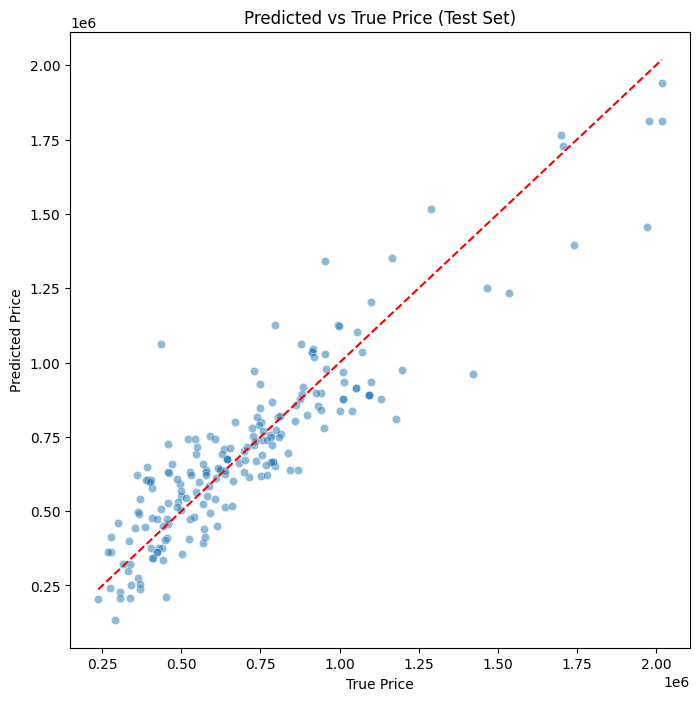

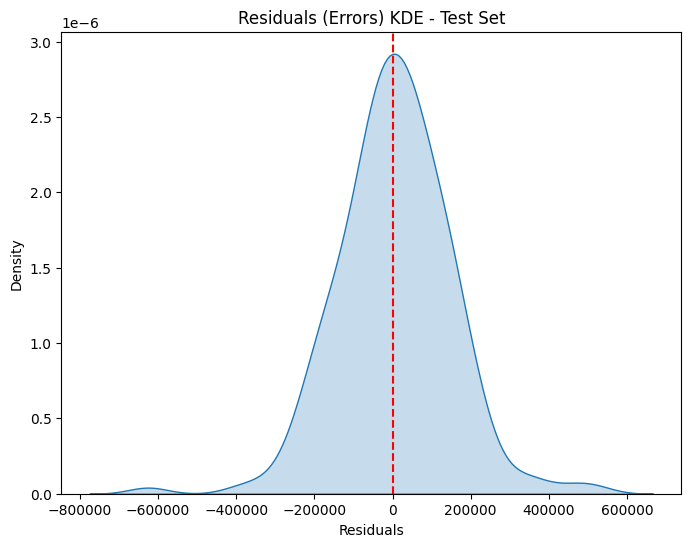

In [82]:
# Q6: The predicted and actual values display the same trends but still are not completely predicted. The residuals display an approximately
# normal distribution (bell shaped around zero). THe model has high predictive ability, but not very much interpretive ability.
numeric_cols = train.select_dtypes(include=np.number).columns.tolist()
numeric_cols.remove('Price')
cat_cols = [c for c in train.select_dtypes(include='object').columns if c != 'Price']
X_train_cat = pd.get_dummies(train[cat_cols], drop_first=True, dtype=float).reset_index(drop=True)
X_test_cat = pd.get_dummies(test[cat_cols], drop_first=True, dtype=float).reset_index(drop=True)
X_test_cat = X_test_cat.reindex(columns=X_train_cat.columns, fill_value=0)
poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_num_poly = pd.DataFrame(poly.fit_transform(train[numeric_cols]), index=X_train_cat.index)
X_test_num_poly = pd.DataFrame(poly.transform(test[numeric_cols]), index=X_test_cat.index)
X_train_num_poly.columns = X_train_num_poly.columns.astype(str)
X_test_num_poly.columns = X_test_num_poly.columns.astype(str)
X_train_all = pd.concat([X_train_num_poly, X_train_cat], axis=1)
X_test_all = pd.concat([X_test_num_poly, X_test_cat], axis=1)
y_train_num = y_train.reset_index(drop=True)
y_test_num = y_test.reset_index(drop=True)
model = LinearRegression()
model.fit(X_train_all, y_train_num)
y_test_pred = model.predict(X_test_all)
plt.figure(figsize=(8,8))
sns.scatterplot(x=y_test_num, y=y_test_pred, alpha=0.5)
plt.plot([y_test_num.min(), y_test_num.max()],
         [y_test_num.min(), y_test_num.max()],
         color='red', linestyle='--')  # diagonal line
plt.xlabel('True Price')
plt.ylabel('Predicted Price')
plt.title('Predicted vs True Price (Test Set)')
plt.show()
residuals = y_test_num - y_test_pred

plt.figure(figsize=(8,6))
sns.kdeplot(residuals, fill=True)
plt.axvline(0, color='red', linestyle='--')
plt.xlabel('Residuals')
plt.ylabel('Density')
plt.title('Residuals (Errors) KDE - Test Set')
plt.show()

**Q4.** Let's explore multiple linear regression in a two-variable case, to build more intuition about what is happening.

Suppose the model is
$$
\hat{y}_i = b_0 + b_1 z_{i1} + b_2 z_{i2}
$$
Assume that $z_{ij}$ is centered or de-meaned, so that $z_{ij} = x_{ij} - m_j$ where $m_j$ is the mean of variable $j$ and $x_{ij}$ is the original value of variable $j$ for observation $i$. Notice that this implies
$$
\dfrac{1}{N} \sum_{i=1}^N z_{ij} = 0
$$
which will simplify your calculations below substantially!

1. Write down the SSE for this model.

$$
SSE = \sum_{i=1}^N (y_i - \hat{y}_i)^2 = \sum_{i=1}^N (y_i - b_0 - b_1 z_{i1} - b_2 z_{i2})^2
$$

2. Take partial derivatives with respect to $b_0$, $b_1$, and $b_2$.

$$
\frac{\partial SSE}{\partial b_0} = -2 \sum_{i=1}^N (y_i - b_0 - b_1 z_{i1} - b_2 z_{i2}) = 0
$$

$$
\frac{\partial SSE}{\partial b_1} = -2 \sum_{i=1}^N z_{i1} (y_i - b_0 - b_1 z_{i1} - b_2 z_{i2}) = 0
$$

$$
\frac{\partial SSE}{\partial b_2} = -2 \sum_{i=1}^N z_{i2} (y_i - b_0 - b_1 z_{i1} - b_2 z_{i2}) = 0
$$

3. Verify that the average error is zero and $e \cdot z =0$ at the optimum, just as in the single linear regression case.

The derivative wrt b0 is:

$$
\sum_i (y_i - b_0) = 0 \implies b_0^* = \bar{y}
$$

$$
\sum_i e_i = \sum_i (y_i - \hat{y}_i) = 0
$$

4. Show that the optimal intercept is $b_0^* = \bar{y}$. Eliminate $b_0^*$ from the remaining equations, and focus on $b_1$ and $b_2$.

$$
\sum_i z_{i1} (y_i - \bar{y} - b_1 z_{i1} - b_2 z_{i2}) = 0
$$

$$
\sum_i z_{i2} (y_i - \bar{y} - b_1 z_{i1} - b_2 z_{i2}) = 0
$$

5. Write your results as a matrix equation in the form "$Ab=C$". These are called the **normal equations**.

$$
Z =
\begin{bmatrix}
z_{11} & z_{12} \\
z_{21} & z_{22} \\
\vdots & \vdots \\
z_{N1} & z_{N2}
\end{bmatrix}, \quad
b =
\begin{bmatrix} b_1 \\ b_2 \end{bmatrix}, \quad
e_c =
\begin{bmatrix} y_1 - \bar{y} \\ y_2 - \bar{y} \\ \vdots \\ y_N - \bar{y} \end{bmatrix}
$$

6. Divide both sides by $N$ and substitute $z_{ij} = x_{ij} - m_j$ back into your normal equations for $x_{ij}$. What is the matrix $A$? What is the vector $C$? Explain the intuition of your discovery.